# Begin

In [1]:
# @launchit.collected

In [2]:
import os # @launchit.collect
import sys # @launchit.collect
import copy
from collections import namedtuple, defaultdict # @launchit.collect
import json
import datetime
import pprint
from functools import cache
import re
import pickle
from unittest.mock import Mock
import dataclasses # @launchit.collect
from dataclasses import dataclass # @launchit.collect
import IPython
from enum import Flag, StrEnum, auto # @launchit.collect
import multiprocessing as mp

from tqdm.notebook import tqdm

import lark # @launchit.collect

import numpy as np
import cupy as cp
import einops
import scipy.linalg
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim
from torch.utils.data import DataLoader, StackDataset
from torchvision import datasets

import optuna 
from optuna.storages import JournalStorage 
from optuna.storages.journal import JournalFileBackend 
from optuna.trial import TrialState

project_root_path = '${PROJECT_ROOT_PATH}' # @launchit.collect
# @launchit.disable
project_root_path = ! git rev-parse --show-toplevel
project_root_path = project_root_path[0]
# @launchit.stop

sys.path.append(os.path.join(project_root_path, 'lib')) # @launchit.collect
from utils import * # @launchit.collect
from logging_utils import *
from model_registry import *
from torch_helpers import *
import launchit # @launchit.disable
import optuna_multiprocessing  # @launchit.collect
from metrics_collector import RmqSummaryWriter
from autoincrement import Autoincrement

# Setup

In [3]:
ArrayUtils.init()
LOG = Logging.get()
RNG = np.random.default_rng()
METRICS_SUITE = defaultdict(list)

class ExecMode(StrEnum):
    MASTER_NOTEBOOK = auto()
    LAUNCH_NOTEBOOK = auto()
    LAUNCH_MODULE = auto()

CONFIG = namedtuple('Config', 
                    'project_root_path, project_root_uri, subproject_path, data_path, mnist_path, private_data_path, run_path, ' + 
                    'self_fname, self_name, ' +
                    'subproject_name,' +
                    'is_cuda, cuda_device, exec_mode, is_interactive')(
    project_root_path=project_root_path,
    project_root_uri=f'com.develorium.{os.path.basename(project_root_path)}',
    subproject_path=os.path.abspath('.'),
    data_path=os.path.join(project_root_path, 'data'),
    mnist_path=os.path.join(project_root_path, 'data', 'mnist'),
    private_data_path=None,
    run_path=None,
    self_fname=None,
    self_name=None,
    subproject_name=None,
    is_cuda=torch.cuda.is_available(),
    cuda_device='cuda' if torch.cuda.is_available() else 'cpu',
    exec_mode=ExecMode.MASTER_NOTEBOOK,
    is_interactive=True,
)

if IPython.get_ipython() is None:
    module_fname = __file__
    module_basename = os.path.basename(module_fname)
    module_name, _ = os.path.splitext(module_basename)
    
    CONFIG = CONFIG._replace(self_fname=module_fname, self_name=module_name)
    CONFIG = CONFIG._replace(exec_mode=ExecMode.LAUNCH_MODULE)
else:
    with open(IPython.get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
        notebook_fname = json.load(cf)['jupyter_session']
        notebook_basename = os.path.basename(notebook_fname)
        notebook_name, notebook_ext = os.path.splitext(notebook_basename)
    
        m = re.match(r'(\w+)-Copy\d+$', notebook_name)
    
        if m: notebook_name = m.group(1) # e.g. Cuml is used to be launched from the copy of the notebook

        CONFIG = CONFIG._replace(self_fname=notebook_fname, self_name=notebook_name)
        
        is_launch = re.match(r'\w+-launch\d+$', notebook_name) is not None
        CONFIG = CONFIG._replace(exec_mode=ExecMode.MASTER_NOTEBOOK if not is_launch else ExecMode.LAUNCH_NOTEBOOK)

CONFIG = CONFIG._replace(is_interactive=CONFIG.exec_mode != ExecMode.LAUNCH_MODULE)

LOG.app_name = CONFIG.self_name
LOG.enable('syslog', not CONFIG.is_interactive)
LOG.enable('stdout', CONFIG.is_interactive)

CONFIG = CONFIG._replace(subproject_name=os.path.basename(os.path.dirname(CONFIG.self_fname)))
CONFIG = CONFIG._replace(run_path=os.path.join(project_root_path, 'run', CONFIG.subproject_name))
CONFIG = CONFIG._replace(private_data_path=os.path.join(CONFIG.data_path, CONFIG.subproject_name))
LOG(f'CONFIG=\n{pprint.pformat(CONFIG._asdict(), sort_dicts=False)}\n', when=CONFIG.is_interactive)
LOG(f'CONFIG={CONFIG._asdict()}', when=not CONFIG.is_interactive)

os.makedirs(CONFIG.private_data_path, exist_ok=True)
os.makedirs(CONFIG.run_path, exist_ok=True)

CONFIG=
{'project_root_path': '/home/misha/dev/mine/neurovision',
 'project_root_uri': 'com.develorium.neurovision',
 'subproject_path': '/home/misha/dev/mine/neurovision/15_transformer',
 'data_path': '/home/misha/dev/mine/neurovision/data',
 'mnist_path': '/home/misha/dev/mine/neurovision/data/mnist',
 'private_data_path': '/home/misha/dev/mine/neurovision/data/15_transformer',
 'run_path': '/home/misha/dev/mine/neurovision/run/15_transformer',
 'self_fname': '/home/misha/dev/mine/neurovision/15_transformer/15_vocab_01.ipynb',
 'self_name': '15_vocab_01',
 'subproject_name': '15_transformer',
 'is_cuda': True,
 'cuda_device': 'cuda',
 'exec_mode': <ExecMode.MASTER_NOTEBOOK: 'master_notebook'>,
 'is_interactive': True}



In [4]:
# @launchit.disable
# @launchit.collect
class LaunchGoal(StrEnum):
    UNSPECIFIED = auto()
    TRAIN_MODEL = auto()

class LaunchGoalObj(namedtuple('LaunchGoalObj', 'goal, model_group_uri, model_name, model_version, model_main_asset_fname')):
    def matches(self, *g):
        if CONFIG.exec_mode == ExecMode.MASTER_NOTEBOOK:
            return True
            
        if g and isinstance(g[0], list):
            assert len(g) == 1
            return self.goal in g[0]

        return self.goal in g

LAUNCH_GOAL = LaunchGoalObj(
    goal=LangUtils.from_str(LaunchGoal, '${LAUNCH_GOAL}', LaunchGoal.UNSPECIFIED),
    model_group_uri='${MODEL_GROUP_URI}',
    model_name='${MODEL_NAME}',
    model_version=LangUtils.from_str(int, '${MODEL_VERSION}', 0),
    model_main_asset_fname='${LAUNCHIT_FNAME}',
)
# @launchit.stop

LAUNCH_GOAL = LAUNCH_GOAL._replace(goal=LaunchGoal.UNSPECIFIED)
LAUNCH_GOAL = LAUNCH_GOAL._replace(model_group_uri=f'{CONFIG.project_root_uri}.{CONFIG.subproject_name}')
LAUNCH_GOAL = LAUNCH_GOAL._replace(model_name=CONFIG.self_name)
LAUNCH_GOAL = LAUNCH_GOAL._replace(model_version=0)
LAUNCH_GOAL = LAUNCH_GOAL._replace(model_main_asset_fname=CONFIG.self_fname)
# @launchit.stop

LOG(f'LAUNCH_GOAL=\n{pprint.pformat(LAUNCH_GOAL._asdict(), sort_dicts=False)}', when=CONFIG.is_interactive)
LOG(f'LAUNCH_GOAL={LAUNCH_GOAL._asdict()}', when=not CONFIG.is_interactive)

LAUNCH_GOAL=
{'goal': <LaunchGoal.UNSPECIFIED: 'unspecified'>,
 'model_group_uri': 'com.develorium.neurovision.15_transformer',
 'model_name': '15_vocab_01',
 'model_version': 0,
 'model_main_asset_fname': '/home/misha/dev/mine/neurovision/15_transformer/15_vocab_01.ipynb'}


# Hyperparameters

In [5]:
# @launchit.disable
# @launchit.collect
@dataclass
class Hyperparameters:
    random_seed: int = None
    # dataset params
    images_preprocessing: str = None
    patch_size: int = None
    patches_count: int = None
    # basis pursuit params
    basis_pursuit_solver: str = None # ISTA, LISTA
    basis_pursuit_rho: float = None
    basis_pursuit_gamma: float = None
    basis_pursuit_init_method: str = None # zero, predict
    basis_pursuit_iters_count: int = None
    # model params
    vocab_size: int = None
    with_gain: bool = None
    kx_nonlinearity: str = None
    # training params
    kx_loss: str = None
    wz_loss_weight: float = None
    kx_loss_weight: float = None
    kx_sparsity_loss_weight: float = None
    z_sparsity_loss_weight: float = None
    with_basis_norm: bool = None
    batch_size: int = None
    epochs_count: int = None
    optimizer: str = None
    learn_rate: float | str = None

    @staticmethod
    def from_dict(d):
        hp = Hyperparameters(**d)
        return hp

    def _asdict(self):
        return dataclasses.asdict(self)

HP = Hyperparameters()
HP.random_seed = 42
HP.patch_size = 5


In [6]:
@dataclass
class LearnRateParams: 
    Plateau = namedtuple('Plateau', 'factor patience')
    
    learn_rate: float = None
    plateau: object = None

def get_lark_tree_value(tree, var_name, default_value=None):
    try:
        return next(tree.scan_values(lambda i: i.type == var_name)).value
    except StopIteration:
        return default_value

def hp_parse_learn_rate(self):
    params = LearnRateParams()

    if isinstance(self.learn_rate, float):
        params.learn_rate = self.learn_rate
        return params
        
    grammar = '''
        spec: initial_lr_spec(","plateau_spec)?
    
        initial_lr_spec: INITIAL_LR
        INITIAL_LR: NUMBER
    
        plateau_spec: "plateau" "(" (|plateau_params_spec ("," plateau_params_spec)*) ")"
        plateau_params_spec: plateau_factor_spec | plateau_patience_spec
        plateau_factor_spec: "factor" "=" plateau_factor_value_spec
        plateau_factor_value_spec: PLATEAU_FACTOR_VALUE
        plateau_patience_spec: "patience" "=" plateau_patience_value_spec
        plateau_patience_value_spec: PLATEAU_PATIENCE_VALUE
        PLATEAU_FACTOR_VALUE: NUMBER
        PLATEAU_PATIENCE_VALUE: NUMBER
        
        %import common.NUMBER
        %import common.WS
        %ignore WS
    '''
    parser = lark.Lark(grammar, start='spec')
    tree = parser.parse(self.learn_rate)
    gtv = lambda var_name, default_value='': get_lark_tree_value(tree, var_name, default_value)
    params.learn_rate = float(gtv('INITIAL_LR'))
    
    if list(tree.find_data('plateau_spec')):
        params.plateau = LearnRateParams.Plateau(
            factor=float(gtv('PLATEAU_FACTOR_VALUE', 0.1)),
            patience=int(gtv('PLATEAU_PATIENCE_VALUE', 10)),
        )

    return params

Hyperparameters.parse_learn_rate = hp_parse_learn_rate

In [7]:
# @launchit.disable
x = Hyperparameters(learn_rate='0.005,plateau(factor=0.115, patience=15)')
lr_params = x.parse_learn_rate()
o = torch.optim.Adam(params=[nn.Parameter(torch.tensor(1.))])
p = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=o, **lr_params.plateau._asdict())
lr_params.learn_rate, p.factor, p.patience

(0.005, 0.115, 15)

# Launch

## new_model_registry

In [8]:
def new_model_registry(is_real=None):
    is_launch = CONFIG.exec_mode in [ExecMode.LAUNCH_NOTEBOOK, ExecMode.LAUNCH_MODULE]
    is_real = is_real if is_real is not None else is_launch

    if not is_real:
        mr = Mock()
        mr.register_model.return_value = 0
        return mr
        
    return ModelRegistry(LAUNCH_GOAL.model_group_uri)

## new_summary_writer

In [9]:
def new_summary_writer(log_dir, is_real=None):
    is_launch = CONFIG.exec_mode in [ExecMode.LAUNCH_NOTEBOOK, ExecMode.LAUNCH_MODULE]
    is_real = is_real if is_real is not None else is_launch

    if not is_real:
        sw = Mock()
        sw.flush.side_effect = sw.reset_mock # to get rid of all recorded call_args_list, which might be heavy (e.g. add_figure)
        return sw
    
    return RmqSummaryWriter(log_dir)

## Bootstrap

In [10]:
optuna_trial = optuna_multiprocessing.get_trial()
optuna_trial_subdir_name = ''

if optuna_trial is not None:
    optuna_trial.set_user_attr('MODEL_VERSION', LAUNCH_GOAL.model_version)
    study_serial = optuna_trial.user_attrs['STUDY_SERIAL']
    optuna_trial_subdir_name = f'opt_{study_serial}'
    LOG(f'Optuna {optuna_trial.number=}, {optuna_trial.user_attrs=}')

LOG(f'HP={HP._asdict()}', when=not CONFIG.is_interactive)
    
if HP.random_seed is not None:
    torch.manual_seed(HP.random_seed)
    RNG = np.random.default_rng(HP.random_seed)    
    LOG(f'Random seed={HP.random_seed}')

model_registry = new_model_registry()
model_registry.attach_asset(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, CONFIG.self_fname, replace=True)
    
meta = dict(
    optuna_trial_number=getattr(optuna_trial, 'number', None),
    hypers=HP._asdict(), 
    config=CONFIG._asdict(), 
)

with io.StringIO() as b:
    json.dump(meta, b)
    model_registry.attach_asset(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, b, asset_ext='json', asset_classifier='meta', replace=True)

summary_log_dir = LAUNCH_GOAL.model_name
summary_log_dir = os.path.join(summary_log_dir, optuna_trial_subdir_name) if optuna_trial_subdir_name != '' else summary_log_dir 
summary_log_dir = os.path.join(summary_log_dir, str(LAUNCH_GOAL.model_version))
LOG(f'Tensorboard run={summary_log_dir}')
summary_writer = new_summary_writer(log_dir=summary_log_dir)
summary_writer.add_text('hypers', pprint.pformat(HP._asdict(), sort_dicts=False), 1)
summary_writer.add_text('config', pprint.pformat(CONFIG._asdict(), sort_dicts=False), 1)

Random seed=42
Tensorboard run=15_vocab_01/0


<Mock name='mock.add_text()' id='135217332273568'>

# Images

## get_mnist_images

In [11]:
def get_mnist_images(subdataset='TRAIN'):
    assert subdataset in ['TRAIN', 'TEST'], f'Unsupported subdataset={subdataset}'
    d = datasets.MNIST(CONFIG.mnist_path, train=subdataset=='TRAIN', download=True)
    images = d.data.numpy()
    images = images.astype('float32')
    image_labels = d.targets
    return images, image_labels

## UninormScaler

In [12]:
class UninormScaler:
    def __init__(self, divisor=255.0):
        self.divisor = divisor
        
    def fit_transform(self, images):
        return self.transform(images)

    def transform(self, images):
        return images / self.divisor

## SampleWiseScaler

In [13]:
# https://gist.github.com/kocherovms/ca352c30fe3eea0f155d4862ddde6e3a for tests and breakdown
class SampleWiseScaler:
    def fit_transform(self, images):
        return self.transform(images)

    # Images are expected to be in raveled (flattened) mode => only last dim is taken into account
    def transform(self, images):
        shape = images.shape
        images = images.reshape(-1, images.shape[-1]) # get rid of all dimensions except the last one
        means = images.mean(axis=-1)
        stds = images.std(axis=-1)
        images = images.T - means
        images = images / np.where(stds != 0, stds, 1)
        images = images.T
        return images.reshape(shape)

## preprocess_images

In [14]:
# images are expected to be in raveled (flattened) mode
def preprocess_images(images, preprocessing_method, scaler=None):
    match preprocessing_method:
        case 'UNINORM':
            scaler = UninormScaler() if scaler is None else scaler
            images = scaler.fit_transform(images)
        case 'SAMPLE_WISE':
            scaler = SampleWiseScaler() if scaler is None else scaler
            images = scaler.fit_transform(images)
        case 'MIN_MAX':
            scaler = MinMaxScaler() if scaler is None else scaler
            images = scaler.fit_transform(images)
        case 'STANDARDIZE':
            scaler = StandardScaler() if scaler is None else scaler
            images = scaler.fit_transform(images)
        case 'ZCA_WHITEN':
            scaler = StandardScaler(with_std=False) if scaler is None else scaler
            images = scaler.fit_transform(images)
            
            Σ = np.cov(images, rowvar=False)
            u, s, _ = np.linalg.svd(Σ)
            images = (u @ np.diag(1.0 / np.sqrt(s + 1e-6)) @ u.T @ images.T).T
        case 'ZCA_HFR30_WHITEN': # HFR30 - Remove 30% of High Frequencies
            scaler = StandardScaler(with_std=False) if scaler is None else scaler
            images = scaler.fit_transform(images)
    
            Σ = np.cov(images, rowvar=False)
            eigvals, eigvecs = np.linalg.eig(Σ)
            eigvals_order = np.argsort(-eigvals)
            wipeout_inds = eigvals_order[int(len(eigvals_order) * (1 - 0.3)):]
            eigvals_w = eigvals.copy()
            eigvals_w[wipeout_inds] = 0
            
            R, S = eigvecs, np.diag(np.sqrt(eigvals_w)) # R - rotation matrix, S - scale matrix
            S_inv = np.reciprocal(S, out=np.zeros_like(S), where=(S != 0))
            R_inv = R.T
            W = R @ S_inv @ R_inv  # equiv. to: R @ np.eye(len(S_inv)) @ S_inv @ R_inv
            images = (W @ images.T).T
        case 'NONE':
            pass
        case _:
            assert False, f'Unsupported preprocessing_method={preprocessing_method}'

    return images, scaler

## extract_image_patch

In [15]:
ImagePatch = namedtuple('ImagePatch', 'patch image_ind i_off j_off')

def extract_image_patch(images, image_stds, patch_size, image_ind=None, with_std=True):
    blind_area = 4
    trials = 1000
    image_ind = RNG.choice(images.shape[0]) if image_ind is None else image_ind
    image = images[image_ind]
    image_std_thres = image_stds[image_ind] * .1

    for _ in range(trials):
        i_off = blind_area + RNG.choice(image.shape[0] - 2 * blind_area - patch_size)
        j_off = blind_area + RNG.choice(image.shape[1] - 2 * blind_area - patch_size)
        patch = image[i_off:i_off + patch_size, j_off:j_off + patch_size]
        
        if with_std:
            patch_std = patch.ravel().std()
    
            if patch_std < image_std_thres: # This should effectively exclude completely monotonic images (e.g. black or white)
                continue
        
        break
    else:
        assert False, f'Failed to extract image patch within {trials} trials'
    
    return ImagePatch(patch, image_ind, i_off, j_off)

# Dataset

In [53]:
# @launchit.disable
# @launchit.collect_1
HP.images_preprocessing = 'UNINORM' # NONE, UNINORM, SAMPLE_WISE, MIN_MAX, STANDARDIZE, ZCA_WHITEN, ZCA_HFR30_WHITEN
HP.patch_size = 9
HP.patches_count = 50_000

## get_dataset_fname

In [54]:
def get_dataset_fname():
    fname = f'patches_{HP.patches_count}_{HP.images_preprocessing}_{HP.patch_size}.npy' 
    return os.path.join(CONFIG.private_data_path, fname)

## Generate patches

In [55]:
# @launchit.disable
assert CONFIG.exec_mode == ExecMode.MASTER_NOTEBOOK
fname = get_dataset_fname()

if not os.path.exists(fname):
    PATCHES = None
    LOG(f'"{fname}" not found, generating new one')
else:
    PATCHES = np.load(fname)
    shape = einops.parse_shape(PATCHES, 'b h w')

    if shape['b'] != HP.patches_count or shape['h'] != HP.patch_size or shape['w'] != HP.patch_size:
        PATCHES = None
        LOG(f'Patches disagree with hyperparameters, regenerating')

if PATCHES is None:
    PATCHES = []
    images, _ = get_mnist_images('TRAIN')
    images, _ = preprocess_images(images, HP.images_preprocessing)
    image_stds = einops.rearrange(images, 'b h w -> b (h w)').std(axis=1)
    
    for i in tqdm(range(HP.patches_count)):
        patch = extract_image_patch(images, image_stds, HP.patch_size, with_std=True)
        PATCHES.append(patch.patch)

    PATCHES = np.array(PATCHES)
    np.save(fname, PATCHES)
    LOG(f'Patches generated and saved to "{fname}"')

"/home/misha/dev/mine/neurovision/data/15_transformer/patches_50000_UNINORM_9.npy" not found, generating new one


  0%|          | 0/50000 [00:00<?, ?it/s]

Patches generated and saved to "/home/misha/dev/mine/neurovision/data/15_transformer/patches_50000_UNINORM_9.npy"


## Load patches

In [19]:
fname = get_dataset_fname()
assert os.path.exists(fname), f'"{fname}" not found'
PATCHES = np.load(fname)
shape = einops.parse_shape(PATCHES, 'b h w')
assert shape['b'] == HP.patches_count
assert shape['h'] == HP.patch_size
assert shape['w'] == HP.patch_size
PATCHES = einops.rearrange(PATCHES, 'b h w -> b (h w)')
LOG(f'Patches loaded from "{fname}": shape={PATCHES.shape}, min={PATCHES.min().item()}, max={PATCHES.max().item()}, std={PATCHES.std().item()}')

Patches loaded from "/home/misha/dev/mine/neurovision/data/15_transformer/psd_patches_50000_UNINORM_5.npy": shape=(50000, 25), min=0.0, max=1.0, std=0.4275371730327606


## Demo

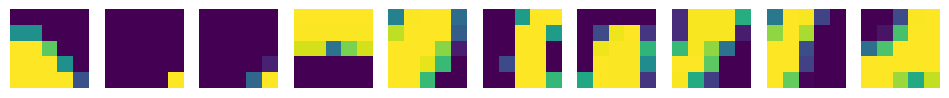

In [20]:
# @launchit.disable
fig, axes = plt.subplots(1, 10)
fig.set_figwidth(12)
patch_inds = RNG.choice(len(PATCHES), len(axes), replace=False)

for patch_ind, ax in zip(patch_inds, axes):
    patch = PATCHES[patch_ind]
    ax.set_axis_off()
    ax.imshow(ArrayUtils.v2sm(patch))

# Basis pursuit

## ISTA (CPU)

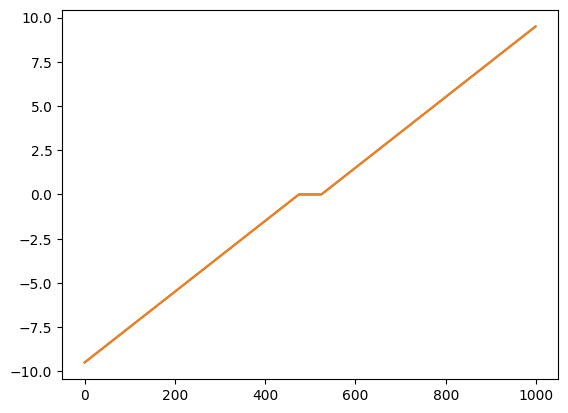

In [21]:
# @launchit.disable
shrink = torch.nn.Softshrink(lambd=0.5)
x = torch.linspace(-10, +10, 1000)
y = shrink(x)
y2 = torch.where(x > shrink.lambd, x - shrink.lambd, torch.where(x < -shrink.lambd, x + shrink.lambd, 0))
plt.plot(y)
plt.plot(y2)
assert torch.all(y == y2)

In [22]:
# import torch
# import torch.nn as nn

# def psd_ista_inner_loop(x, encoder_pred, D, lambd, gamma, alpha, max_iter=50):
#     """
#     Finds the optimal sparse code 'z' for PSD.
    
#     Args:
#         x: Input data [batch_size, input_dim]
#         encoder_pred: Initial code predicted by the encoder f(x)
#         D: Decoder dictionary weights [input_dim, code_dim]
#         lambd: L1 sparsity penalty weight
#         gamma: Prediction agreement weight ||z - f(x)||^2
#         alpha: Step size (1/Lipschitz constant)
#         max_iter: Number of ISTA iterations
#     """
#     # Initialize z with the encoder's prediction for faster convergence
#     z = encoder_pred.clone().detach()
    
#     # Soft-thresholding operator for L1 regularization
#     shrink = nn.Softshrink(lambd * alpha)
    
#     for _ in range(max_iter):
#         # 1. Gradient of reconstruction term: ||x - Dz||^2
#         # d/dz = -D^T (x - Dz)
#         recon_grad = (z @ D.t() - x) @ D
        
#         # 2. Gradient of prediction term: gamma * ||z - f(x)||^2
#         # d/dz = gamma * (z - f(x))
#         pred_grad = gamma * (z - encoder_pred)
        
#         # 3. Total gradient step
#         total_grad = recon_grad + pred_grad
#         z_next = z - alpha * total_grad
        
#         # 4. Proximal mapping (Shrinkage)
#         z = shrink(z_next)
        
#     return z

In [23]:
def ista(x, W, init_z, pred_z, rho=0.5, gamma=0.1, L=1, iters_count=300):
    # W = matrix, wich each column is a basis
    z = init_z
    alpha = 1 / L # L - Lipschitz constant
    lambd = rho * alpha
    
    for _ in range(iters_count):
        recon_grad = W.T @ (W @ z - x) # turn z to pred_x, compute diff and turn diff back to z space
        pred_grad = gamma * (z - pred_z)
        total_grad = recon_grad + pred_grad
        
        z_next = z - alpha * total_grad
        # soft shrink
        z = np.where(
            z_next > lambd, 
            z_next - lambd, 
            np.where(
                z_next < -lambd, 
                z_next + lambd, 
                0)
            )
        
    return z

In [24]:
X = RNG.normal(size=(1, 25)) # 1 sample of 25 dims
W = RNG.normal(size=(X.shape[1], 32)) # 32 bases each of 25 dims (each base is a column)
Z = np.zeros((X.shape[0], W.shape[1]))
max_index = W.shape[1] - 1
L = scipy.linalg.eigvalsh(W.T @ W, subset_by_index=(max_index, max_index)).item()
ista(X[0], W, init_z=np.zeros_like(Z[0]), pred_z=Z[0], rho=0.5, gamma=0.1, L=L, iters_count=10)    

array([ 0.06374436,  0.24728951, -0.08851878, -0.01531329, -0.12896685,
        0.11905239,  0.04132202,  0.        ,  0.09117033, -0.00526474,
       -0.10617699, -0.02425556,  0.10165926,  0.17631717, -0.2595414 ,
       -0.09802527,  0.06588468,  0.00472139, -0.04723478, -0.06684501,
        0.00318032, -0.04002591, -0.04251295, -0.05623942,  0.14821126,
        0.        , -0.11798002, -0.03265078, -0.09260671,  0.        ,
       -0.0354023 , -0.14461765])

## ISTA (CUDA)

In [25]:
if CONFIG.is_cuda:
    cuda_ista = cp.RawKernel(r'''
    #include <assert.h>
    #include <math.h>
    
    static __device__
    void softshrink(float * const theVector, const int theVectorSize, const float theLambda) {
        assert(theLambda > 0);
        
        for(int i = 0; i < theVectorSize; i++) {
            if(abs(theVector[i]) <= theLambda) {
                theVector[i] = 0;
            }
            else {
                theVector[i] += theVector[i] < 0 ? theLambda : -theLambda;
            }
        }
    }
    
    static __device__
    float dotProduct(const float * const theVector1, const float * const theVector2, const int theVectorSize) {
        float r = 0;
    
        for(int i = 0; i < theVectorSize; i++) {
            r += theVector1[i] * theVector2[i];
        }
    
        return r;
    }
    
    static __device__
    void loadVector(float * theVector, const float * theMatrix, const int theN, const int theM, const int theRow, const int theColumn) {
        assert((theRow >= 0) ^ (theColumn >= 0));
    
        if(theRow >= 0) {
            assert(theRow < theN);
            const float * const row = theMatrix + theRow * theM;
            
            for(int j = 0; j < theM; j++) {
                theVector[j] = row[j];
            }
        }
        else if(theColumn >= 0) {
            assert(theColumn < theM);
            const float * const column = theMatrix + theColumn;
    
            for(int i = 0; i < theN; i++) {
                theVector[i] = column[i * theM];
            }
        }
    }
    
    static const int MAX_INPUT_SIZE = 256;
    static const int MAX_BASES_COUNT = 256;
    
    extern "C" __global__
    void ista(
        // INPUT
        const int theInputsCount,
        const int theInputSize,
        const float * const theInputsMatrix, // matrix[theInputsCount][theInputSize]
        const int theBasesCount,
        const float * const theBasesMatrix, // matrix[theInputSize][theBasesCount], COLUMN BASED LAYOUT!
        const float * const theInitCoeffsMatrix, // // matrix[theInputsCount][theBasesCount]
        const float * const thePredCoeffsMatrix, // // matrix[theInputsCount][theBasesCount]
        const float theRho, 
        const float theGamma,
        const float theL,
        const int theItersCount,
        // OUTPUT
        float * const theCoeffsMatrix  // matrix[theInputsCount][theBasesCount], 
    ) {
        assert(MAX_INPUT_SIZE >= theInputSize);
        assert(MAX_BASES_COUNT >= theBasesCount);
        assert(theL != 0);
        const int inputInd = blockDim.x * blockIdx.x + threadIdx.x;
    
        if(inputInd >= theInputsCount)
            return;
    
        const auto inputsPtrOffset = inputInd * theInputSize;
        const float * const input = theInputsMatrix + inputsPtrOffset;
        
        const auto coeffsPtrOffset = inputInd * theBasesCount;
        float * const coeffs = theCoeffsMatrix + coeffsPtrOffset;
        const float * const initCoeffs = theInitCoeffsMatrix + coeffsPtrOffset;
        memcpy(coeffs, initCoeffs, sizeof(*coeffs) * theBasesCount);
    
        const float * const predCoeffs = thePredCoeffsMatrix + coeffsPtrOffset;
    
        const float alpha = 1 / theL;
        const float softshrinkLambda = theRho * alpha;
    
        float workVectorInput[MAX_INPUT_SIZE] = {0};
        float workVectorBase[MAX_INPUT_SIZE] = {0};
        float workVectorCoeffs[MAX_BASES_COUNT] = {0};
    
        for(int iter = 0; iter < theItersCount; iter++) {
            // recon_grad = W.T @ (W @ z - x) # turn z to pred_x, compute diff and turn diff back to z space
            // pred_grad = gamma * (z - pred_z)
            // total_grad = recon_grad + pred_grad
            
            // z_next = z - alpha * total_grad
            
            // (W @ z - x) -> workVectorInput
            for(int i = 0; i < theInputSize; i++) {
                loadVector(workVectorCoeffs, theBasesMatrix, theInputSize, theBasesCount, i, -1); // load row
                const float dp = dotProduct(workVectorCoeffs, coeffs, theBasesCount);
                workVectorInput[i] = dp - input[i];
            }
    
            float * const totalGrad = workVectorCoeffs;
            
            // compute recon_grad and store in totalGrad
            for(int j = 0; j < theBasesCount; j++) {
                loadVector(workVectorBase, theBasesMatrix, theInputSize, theBasesCount, -1, j); // load column
                const float dp = dotProduct(workVectorBase, workVectorInput, theInputSize);
                totalGrad[j] = dp;
            }
    
            // compute pred_grad and update totalGrad in place
            for(int j = 0; j < theBasesCount; j++) {
                totalGrad[j] += theGamma * (coeffs[j] - predCoeffs[j]); 
            }
    
            for(int j = 0; j < theBasesCount; j++) {
                coeffs[j] -= alpha * totalGrad[j];
            }
    
            softshrink(coeffs, theBasesCount, softshrinkLambda);
        }
    }
    ''', 'ista', backend='nvcc')
    cuda_ista.compile()

In [26]:
# @launchit.disable
if CONFIG.is_cuda:
    X = RNG.normal(size=(3, 25)).astype('f') # 3 samples of 25 dims
    W = RNG.normal(size=(X.shape[1], 32)).astype('f') # 32 bases each of 25 dims (each base is a column!)
    Z = np.zeros((X.shape[0], W.shape[1]))
    max_index = W.shape[1] - 1
    L = scipy.linalg.eigvalsh(W.T @ W, subset_by_index=(max_index, max_index)).item()
    
    for i in range(len(X)):
        Z[i] = ista(X[i], W, init_z=Z[i], pred_z=Z[i], rho=0.5, gamma=0.1, L=L, iters_count=10)
    
    cuda_pred_Z = cp.zeros((X.shape[0], W.shape[1]), dtype='f')
    cuda_Z = cp.zeros((X.shape[0], W.shape[1]), dtype='f')
    
    cuda_kernel_params = (
        # INPUT
        cp.int32(X.shape[0]),
        cp.int32(X.shape[1]),
        ArrayUtils.ensure_dtype(ArrayUtils.to_gpu(X), cp.float32),
        cp.int32(W.shape[1]),
        ArrayUtils.ensure_dtype(ArrayUtils.to_gpu(W), cp.float32),
        ArrayUtils.ensure_dtype(cuda_pred_Z, cp.float32),
        ArrayUtils.ensure_dtype(cuda_pred_Z, cp.float32),
        cp.float32(0.5),
        cp.float32(0.1),
        cp.float32(L),
        cp.int32(10),
        # OUTPUT
        ArrayUtils.ensure_dtype(cuda_Z, cp.float32),
    )
    CudaUtils.exec_cuda_kernel(cuda_ista, len(X), cuda_kernel_params)
    assert np.all(np.isclose(Z, ArrayUtils.from_gpu(cuda_Z)))

## batch_ista

In [27]:
def batch_ista(patches, W, init_Z, pred_Z):
    assert init_Z.shape[0] == len(patches)
    assert init_Z.shape[1] == HP.vocab_size
    assert pred_Z.shape == init_Z.shape
    
    max_index = W.shape[1] - 1
    L = scipy.linalg.eigvalsh(W.T @ W, subset_by_index=(max_index, max_index)).item()
    
    if CONFIG.is_cuda:
        cuda_init_Z = ArrayUtils.to_gpu(init_Z)
        cuda_pred_Z = ArrayUtils.to_gpu(pred_Z)
        cuda_Z = cp.zeros((len(patches), HP.vocab_size), dtype='f')
        cuda_kernel_params = (
            # INPUT
            cp.int32(patches.shape[0]),
            cp.int32(patches.shape[1]),
            ArrayUtils.ensure_dtype(ArrayUtils.to_gpu(patches), cp.float32),
            cp.int32(W.shape[1]),
            ArrayUtils.ensure_dtype(ArrayUtils.to_gpu(W), cp.float32),
            ArrayUtils.ensure_dtype(cuda_init_Z, cp.float32),
            ArrayUtils.ensure_dtype(cuda_pred_Z, cp.float32),
            cp.float32(HP.basis_pursuit_rho),
            cp.float32(HP.basis_pursuit_gamma),
            cp.float32(L),
            cp.int32(HP.basis_pursuit_iters_count),
            # OUTPUT
            ArrayUtils.ensure_dtype(cuda_Z, cp.float32),
        )
        CudaUtils.exec_cuda_kernel(cuda_ista, len(patches), cuda_kernel_params)
        return ArrayUtils.from_gpu(cuda_Z)
    else:
        Z = np.zeros((len(patches), HP.vocab_size)).astype('f') 
        
        for ind, patch in enumerate(patches):
            Z[ind] = ista(patch, W, init_z=init_Z[ind], pred_z=pred_Z[ind], rho=HP.basis_pursuit_rho, gamma=HP.basis_pursuit_gamma, L=L, iters_count=HP.basis_pursuit_iters_count)

        return Z

## LISTA

In [28]:
# ...

## batch_solo

Хотим, найти только один, но самый лучший базис. Т.е. что-то типа победитель забирает все (winner takes it all)

In [29]:
# X - patches as rows
# W - bases as columns
# We don't expect anything on W
def batch_solo(X, W):
    # Use broadcasting to get differences
    diff = einops.rearrange(X, 'n d -> n 1 d') - einops.rearrange(W, 'd m -> 1 m d')
    
    if isinstance(diff, torch.Tensor):
        loss_matrix = torch.mean(diff**2, dim=2)
        best_inds = torch.argmin(loss_matrix, dim=1, keepdim=True)
        Z = torch.zeros_like(loss_matrix).scatter_(1, best_inds, 1.0)
    elif isinstance(diff, np.ndarray):
        loss_matrix = (diff ** 2).mean(axis=2)
        best_inds = np.argmin(loss_matrix, axis=1)
        Z = np.zeros_like(loss_matrix)
        Z[np.arange(loss_matrix.shape[0]), best_inds] = 1
    else:
        assert False, f'Unsupported {type(diff)=}'

    return Z   

# X - patches as rows
# W - bases as columns
# We expect that bases in W are normalized
def batch_solo_unused(X, W):
    cos_sims = X @ W 

    if isinstance(cos_sims, torch.Tensor):
        best_inds = torch.argmax(cos_sims, dim=1, keepdim=True)
        Z = torch.zeros_like(cos_sims).scatter_(1, best_inds, 1.0)
    elif isinstance(cos_sims, np.ndarray):
        best_inds = np.argmax(cos_sims, axis=1)
        Z = np.zeros_like(cos_sims)
        Z[np.arange(cos_sims.shape[0]), best_inds] = 1
    else:
        assert False, f'Unsupported {type(cos_sims)=}'
        
    return Z

In [30]:
X = RNG.normal(size=(3, 25)) # 3 sample of 25 dims
W = RNG.normal(size=(X.shape[1], 32)) # 32 bases each of 25 dims (each base is a column)
torch_Z = batch_solo(torch.tensor(X), torch.tensor(W)) # check support for torch.tensor
assert torch.all(torch_Z.sum(dim=1) == 1)
np_Z = batch_solo(X, W) # check support for numpy
assert np.all(np_Z.sum(axis=1) == 1)
assert np.all(torch_Z.numpy() == np_Z)

# Model

## MainModel

In [31]:
class MainModel(nn.Module):
    def __init__(self, hp):
        super().__init__()
        self.W = nn.Linear(in_features=hp.vocab_size, out_features=hp.patch_size**2, bias=False) # matrix of "reverse" filters, each row = dict elem
        self.K = nn.Linear(in_features=hp.patch_size**2, out_features=hp.vocab_size, bias=True) # future kernels (what we want to train in PSD), each row = kernel
        # due to tanh nonlinearity output of tanh(self.K(X)) is limited to -1..+1. Gain is used to scale this value back to what ISTA predicts.
        # N.B.: z coeffs after ISTA may vary in hundreds!
        # [KavukcuogluFastInferSparse]: "gain coefficients allowing the outputs of F to compensate for the scaling of the input,  
        # given that the reconstruction performed by B uses bases with unit norm"
        if not LangUtils.coalesce(hp.with_gain, False):
            self.G = None
        else:
            self.G = nn.Parameter(torch.ones(hp.vocab_size))

        if hp.kx_nonlinearity is None:
            self.kx_nonlinearity = lambda i: i
        else:
            self.kx_nonlinearity = getattr(nn, hp.kx_nonlinearity)()

    ForwardResult = namedtuple('ForwardResult', 'wz kx')

    def forward(self, X, Z):
        # expected X.shape = (batch, image_as_vector)
        # expected Z.shape = (batch, coeffs_as_vector)
        wz = self.W(Z)
        kx = self.predict(X)
        return MainModel.ForwardResult(wz=wz, kx=kx)

    def predict(self, X): # a-la encode
        pred_z = self.kx_nonlinearity(self.K(X))
        
        if self.G is not None:
            pred_z = self.G * pred_z
            
        # expected pred_z.shape = (batch, coeffs_as_vector)
        return pred_z

In [32]:
# @launchit.disable
hp = Hyperparameters(vocab_size=32, patch_size=5, kx_nonlinearity='Sigmoid', with_gain=False)
model = MainModel(hp)
print(model)
print(f'Params count={sum([p.numel() for p in model.parameters()])}')
test_X = torch.ones((100, hp.patch_size**2))
test_Z = torch.ones((100, hp.vocab_size))
fr = model(test_X, test_Z)
print(f'{fr.wz.shape=}, {fr.kx.shape=}')

MainModel(
  (W): Linear(in_features=32, out_features=25, bias=False)
  (K): Linear(in_features=25, out_features=32, bias=True)
  (kx_nonlinearity): Sigmoid()
)
Params count=1632
fr.wz.shape=torch.Size([100, 25]), fr.kx.shape=torch.Size([100, 32])


In [57]:
model.W.weight.shape

torch.Size([25, 32])

# LAUNCH_GOAL.TRAIN_MODEL

## Configure

In [56]:
# @launchit.disable
# @launchit.collect_1
HP.basis_pursuit_solver = 'SOLO'
HP.basis_pursuit_rho = 0.92
HP.basis_pursuit_gamma = 0.97
HP.basis_pursuit_init_method = 'zero'
HP.basis_pursuit_iters_count = 20
HP.vocab_size = 32
HP.kx_nonlinearity = 'Sigmoid'
HP.with_gain = False
HP.kx_loss = 'MSELoss'
HP.wz_loss_weight = 1
HP.kx_loss_weight = 1
HP.kx_sparsity_loss_weight = 1
HP.z_sparsity_loss_weight = 1
HP.batch_size = 100
HP.epochs_count = 2
HP.optimizer = 'Adam'
HP.learn_rate = '0.005,plateau()'
# @launchit.stop
LOG(pprint.pformat(HP._asdict(), sort_dicts=False), when=CONFIG.is_interactive)

{'random_seed': 42,
 'images_preprocessing': 'UNINORM',
 'patch_size': 5,
 'patches_count': 50000,
 'basis_pursuit_solver': 'SOLO',
 'basis_pursuit_rho': 0.92,
 'basis_pursuit_gamma': 0.97,
 'basis_pursuit_init_method': 'zero',
 'basis_pursuit_iters_count': 20,
 'vocab_size': 32,
 'with_gain': False,
 'kx_nonlinearity': 'Sigmoid',
 'wz_loss_weight': 1,
 'kx_loss_weight': 1,
 'kx_sparsity_loss_weight': 1,
 'z_sparsity_loss_weight': 1,
 'with_basis_norm': None,
 'batch_size': 100,
 'epochs_count': 2,
 'optimizer': 'Adam',
 'learn_rate': '0.005,plateau()'}


## Train

In [57]:
main_model = MainModel(HP)
main_model = main_model.to(device=CONFIG.cuda_device)
lr_params = HP.parse_learn_rate()
optimizer = getattr(torch.optim, HP.optimizer)(main_model.parameters(), lr=lr_params.learn_rate)
lr_scheduler = LrSchedulerWrapper(optimizer, lr_params)
PATCHES_CUDA = torch.tensor(PATCHES).to(CONFIG.cuda_device)
kx_loss_fn = getattr(torch.nn, HP.kx_loss)()

for epoch in tqdm(range(HP.epochs_count + 1), desc='Epoch', disable=not CONFIG.is_interactive):
    with LOG.auto_prefix('EPOCH', epoch):
        # Get Z with W and H locked
        with torch.no_grad():
            if HP.basis_pursuit_solver == 'ISTA':
                W = main_model.W.weight.detach().to('cpu').numpy()
                with torch.no_grad(): pred_Z = main_model.predict(PATCHES_CUDA).detach().to('cpu').numpy()
                init_Z = pred_Z if HP.basis_pursuit_init_method == 'predict' else np.zeros_like(pred_Z)
                Z = batch_ista(PATCHES, W, init_Z, pred_Z)
                Z = torch.tensor(Z).to(device=CONFIG.cuda_device)
            elif HP.basis_pursuit_solver == 'LISTA':
                assert False, 'Not implemented'
            elif HP.basis_pursuit_solver == 'SOLO':
                with torch.no_grad(): 
                    Z = batch_solo(PATCHES_CUDA, main_model.W.weight)
            else:
                assert False, f'Unsupported {HP.basis_pursuit_solver=}'
    
        # Train W and K with Z locked
        dataset = StackDataset(PATCHES_CUDA, Z)
        data_loader = DataLoader(dataset, batch_size=HP.batch_size, shuffle=True)
        epoch_loss = dict(all=0, wz=0, kx=0, kx_sparsity=0, z_sparsity=0)
        epoch_loss_denom = 0
    
        for batch in data_loader:
            optimizer.zero_grad()
            fr = main_model(X=batch[0], Z=batch[1])
            wz_loss = F.mse_loss(fr.wz, batch[0])
            kx_loss = kx_loss_fn(fr.kx, batch[1])
            kx_sparsity_loss = fr.kx.abs().sum(axis=1).mean()
            z_sparsity_loss = batch[1].abs().sum(axis=1).mean()
            loss = HP.wz_loss_weight * wz_loss + HP.kx_loss_weight * kx_loss + HP.kx_sparsity_loss_weight * kx_sparsity_loss + HP.z_sparsity_loss_weight * z_sparsity_loss

            if epoch > 0: # first run is a dry run to get losses baseline
                loss.backward()
                optimizer.step()
    
            for k, l in zip(('all', 'wz', 'kx', 'kx_sparsity', 'z_sparsity'), (loss, wz_loss, kx_loss, kx_sparsity_loss, z_sparsity_loss)):
                epoch_loss[k] += l.item() * len(batch)
                
            epoch_loss_denom += len(batch)

        for k in epoch_loss:
            epoch_loss[k] = epoch_loss[k] / epoch_loss_denom
            
        lr_scheduler.step(epoch_loss['all'])
    
        # [KavukcuogluFastInferSparse]: "The columns of B are then re-scaled to unit norm"
        # Norm is needed if we treat column of W as basis and want to be in "linear combination mode"
        # If we treat columns of W as just represntative samples then normalization is under question
        if LangUtils.coalesce(HP.with_basis_norm, False):
            with torch.no_grad():
                # main_model.W stands for B in this model
                norms = torch.linalg.vector_norm(main_model.W.weight, dim=0)
                main_model.W.weight.div_(norms)
                assert torch.all(torch.isclose(torch.linalg.vector_norm(main_model.W.weight, dim=0), torch.tensor(1.0)))
            
        if HP.basis_pursuit_solver == 'LISTA':
            # Train LISTA model for fast Z compute
            assert False, 'Not implemented'
    
        assert epoch_loss_denom > 0

        # Report metrics and upload figures
        concat_log = []
        
        for k, l in epoch_loss.items():
            k = f'loss_{k}'
            summary_writer.add_scalar(k, l, epoch)
            METRICS_SUITE[k].append(l)
            concat_log.append(f'{k}={l:.4g}')
            
        LOG(', '.join(concat_log), when=not CONFIG.is_interactive)

        if optuna_trial is not None:
            # https://optuna.readthedocs.io/en/stable/reference/generated/optuna.trial.Trial.html#optuna.trial.Trial.report:
            # > If this method is called multiple times at the same step in a trial, the reported value only the first time is stored 
            # > and the reported values from the second time are ignored.
            # In other words calling report for fold other than the first one does nothing except producing tons of warnings in console. 
            # As such only the first fold is indicative
            optuna_trial.report(epoch_loss['all'], epoch) 
    
            if optuna_trial.should_prune():
                # Despite written in docs OPTUNA_TRIAL.should_prune is not idempotent - consequent calls could lead
                # to different responses. Perhapse this is due to influence of concurrent trials running which could change
                # pruner decision. As such cache pruning result so it's immutable
                optuna_trial.set_user_attr('IS_PRUNED', True)
                LOG(f'Optuna pruning condition encountered. Stopping training')
                break
    
        upload_figures = True
    
        if upload_figures and ((epoch % 20) == 0 or (epoch == HP.epochs_count)):
            # Upload kernel (filters) images
            kernes_in_row = 8
            max_kernels_to_show = 100
            kernels = main_model.K.weight.to(device='cpu').detach()
            rows_count = int(np.ceil(min(max_kernels_to_show, len(kernels)) / kernes_in_row))
            fig, axes = plt.subplots(rows_count, kernes_in_row, subplot_kw={'yticks': [], 'xticks': []})
            for ax in axes.ravel(): ax.set_axis_off()
            fig.set_figwidth(16)
            fig.set_figheight(rows_count * 1.5)
            
            if main_model.K.bias is not None:
                biases = main_model.K.bias.to(device='cpu').detach()
                kernels = einops.rearrange(kernels, 'k hw -> hw k')
                kernels = kernels + biases
                kernels = einops.rearrange(kernels, 'hw k -> k hw')
            
            for i, (k, ax) in enumerate(zip(kernels, axes.ravel())):
                ax.set_title(f'#{i}', fontdict=dict(fontsize=10))
                im = ax.imshow(ArrayUtils.v2sm(k))
                fig.colorbar(im, ax=ax)
            
            fig.tight_layout()
            summary_writer.add_figure(f'kernels', fig, epoch, close=False)
            plt.close(fig)
            LOG('Figure "kernels" uploaded', when=not CONFIG.is_interactive)

            # Upload dict images
            dict_items_in_row = 8
            max_dict_items_to_show = 100
            dict_items = main_model.W.weight.to(device='cpu').detach().T
            rows_count = int(np.ceil(min(max_dict_items_to_show, len(dict_items)) / dict_items_in_row))
            fig, axes = plt.subplots(rows_count, dict_items_in_row, subplot_kw={'yticks': [], 'xticks': []})
            for ax in axes.ravel(): ax.set_axis_off()
            fig.set_figwidth(16)
            fig.set_figheight(rows_count * 1.5)
            
            for i, (d, ax) in enumerate(zip(dict_items, axes.ravel())):
                ax.set_title(f'#{i}', fontdict=dict(fontsize=10))
                im = ax.imshow(ArrayUtils.v2sm(d))
                fig.colorbar(im, ax=ax)
            
            fig.tight_layout()
            summary_writer.add_figure(f'dict_items', fig, epoch, close=False)
            plt.close(fig)
            LOG('Figure "dict_items" uploaded', when=not CONFIG.is_interactive)
    
            # Upload examples
            if epoch == 0:
                example_inds = RNG.choice(len(PATCHES), 10, replace=False)
                example_patches = PATCHES[example_inds]
                example_patches_torch = torch.tensor(example_patches).to(device=CONFIG.cuda_device)
    
            fig, axes = plt.subplots(5, len(example_inds))
            fig.set_figwidth(16)
            fig.set_figheight(len(axes) * 1.8)
            for ax in axes.ravel(): ax.set_axis_off()
            W = main_model.W.weight.detach().to('cpu').numpy()
            with torch.no_grad(): pred_Z = main_model.predict(example_patches_torch).detach().to('cpu').numpy()

            if HP.basis_pursuit_solver == 'ISTA':
                init_Z = pred_Z if HP.basis_pursuit_init_method == 'predict' else np.zeros_like(pred_Z)
                example_solver_z_list = batch_ista(example_patches, W, init_Z, pred_Z)
            elif HP.basis_pursuit_solver == 'SOLO':
                with torch.no_grad(): 
                    example_solver_z_list = batch_solo(example_patches, W)
            else:
                assert False, f'Unsupported {HP.basis_pursuit_solver=}'
            
            for example_ind, patch, solver_z, pred_z, (ax0, ax11, ax12, ax21, ax22) in zip(example_inds, example_patches, example_solver_z_list, pred_Z, axes.T):
                ax0.set_title(f'#{example_ind}', fontdict=dict(fontsize=10))
                ax0.imshow(ArrayUtils.v2sm(patch))
                
                solver_patch = W @ solver_z
                solver_l = F.mse_loss(torch.tensor(solver_patch), torch.tensor(patch)).item()
                ax11.set_title(f'{HP.basis_pursuit_solver},\nl={solver_l:.2f}', fontdict=dict(fontsize=10))
                ax11.imshow(ArrayUtils.v2sm(solver_patch))
                ax12.set_title(f'min={np.min(solver_z):.2f},\nmax={np.max(solver_z):.2f}', fontdict=dict(fontsize=10))
                ax12.bar(np.arange(len(solver_z)), solver_z)
                
                pred_patch = W @ pred_z
                pred_l = F.mse_loss(torch.tensor(pred_patch), torch.tensor(patch)).item()
                z_l = kx_loss_fn(torch.tensor(pred_z), torch.tensor(solver_z)).item()
                ax21.set_title(f'Predict,\nl={pred_l:.2f}', fontdict=dict(fontsize=10))
                ax21.imshow(ArrayUtils.v2sm(pred_patch))
                ax22.set_title(f'min={np.min(pred_z):.2f},\nmax={np.max(pred_z):.2f},\nl={z_l:.2f}', fontdict=dict(fontsize=10))
                ax22.bar(np.arange(len(pred_z)), pred_z)

            fig.tight_layout()
            summary_writer.add_figure(f'examples', fig, epoch, close=False) 
            plt.close(fig) # manual closing because summar_writer may be in Mock mode leaving fig unclosed
            LOG('Figure "examples" uploaded', when=not CONFIG.is_interactive)
            
        summary_writer.flush()

Epoch:   0%|          | 0/3 [00:00<?, ?it/s]

## Visualize

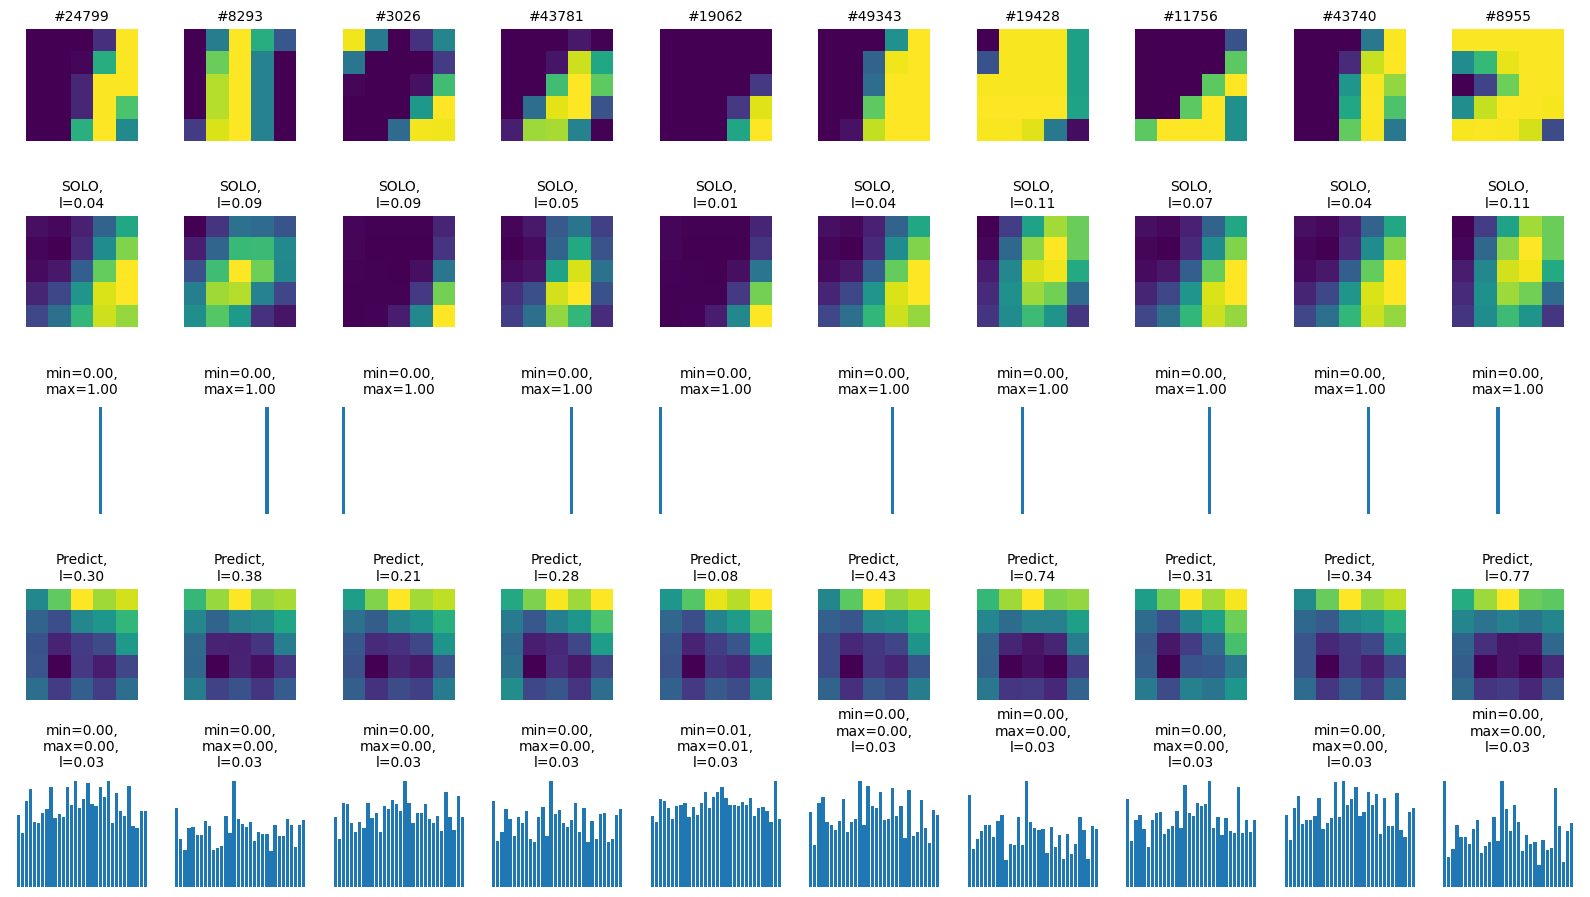

In [58]:
# @launchit.disable
kx_loss_fn = getattr(torch.nn, HP.kx_loss)()
example_inds = RNG.choice(len(PATCHES), 10, replace=False)
example_patches = PATCHES[example_inds]
fig, axes = plt.subplots(5, len(example_inds))
fig.set_figwidth(16)
fig.set_figheight(len(axes) * 1.8)
for ax in axes.ravel(): ax.set_axis_off()
W = main_model.W.weight.detach().to('cpu').numpy()
with torch.no_grad(): pred_Z = main_model.predict(torch.tensor(example_patches).to(device=CONFIG.cuda_device)).detach().to('cpu').numpy()

if HP.basis_pursuit_solver == 'ISTA':
    init_Z = pred_Z if HP.basis_pursuit_init_method == 'predict' else np.zeros_like(pred_Z)
    example_solver_z_list = batch_ista(example_patches, W, init_Z, pred_Z)
elif HP.basis_pursuit_solver == 'SOLO':
    with torch.no_grad(): 
        example_solver_z_list = batch_solo(example_patches, W)
else:
    assert False, f'Unsupported {HP.basis_pursuit_solver=}'
    
for example_ind, patch, solver_z, pred_z, (ax0, ax11, ax12, ax21, ax22) in zip(example_inds, example_patches, example_solver_z_list, pred_Z, axes.T):
    ax0.set_title(f'#{example_ind}', fontdict=dict(fontsize=10))
    ax0.imshow(ArrayUtils.v2sm(patch))
    
    solver_patch = W @ solver_z
    solver_l = F.mse_loss(torch.tensor(solver_patch), torch.tensor(patch)).item()
    ax11.set_title(f'{HP.basis_pursuit_solver},\nl={solver_l:.2f}', fontdict=dict(fontsize=10))
    ax11.imshow(ArrayUtils.v2sm(solver_patch))
    ax12.set_title(f'min={np.min(solver_z):.2f},\nmax={np.max(solver_z):.2f}', fontdict=dict(fontsize=10))
    ax12.bar(np.arange(len(solver_z)), solver_z)
    
    pred_patch = W @ pred_z
    pred_l = F.mse_loss(torch.tensor(pred_patch), torch.tensor(patch)).item()
    z_l = kx_loss_fn(torch.tensor(pred_z), torch.tensor(solver_z)).item()
    ax21.set_title(f'Predict,\nl={pred_l:.2f}', fontdict=dict(fontsize=10))
    ax21.imshow(ArrayUtils.v2sm(pred_patch))
    ax22.set_title(f'min={np.min(pred_z):.2f},\nmax={np.max(pred_z):.2f},\nl={z_l:.2f}', fontdict=dict(fontsize=10))
    ax22.bar(np.arange(len(pred_z)), pred_z)

fig.tight_layout()

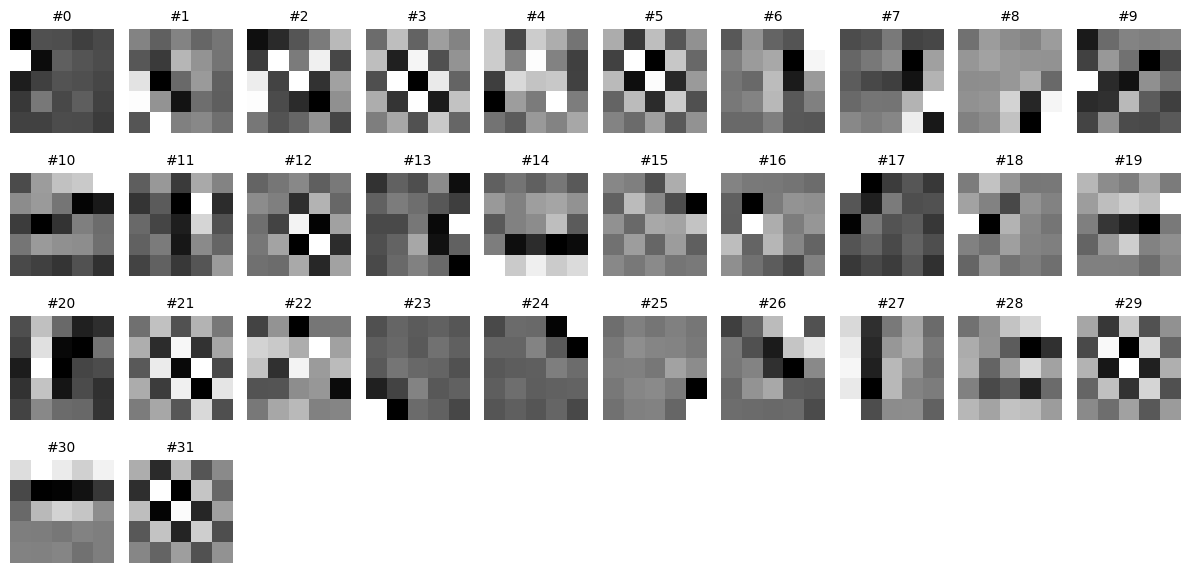

In [43]:
# @launchit.disable
kernes_in_row = 10
max_kernels_to_show = 100
kernels = main_model.K.weight.to(device='cpu').detach()
rows_count = int(np.ceil(min(max_kernels_to_show, len(kernels)) / kernes_in_row))
fig, axes = plt.subplots(rows_count, kernes_in_row, subplot_kw={'yticks': [], 'xticks': []})
for ax in axes.ravel(): ax.set_axis_off()
fig.set_figwidth(12)
fig.set_figheight(rows_count * 1.5)

if main_model.K.bias is not None:
    biases = main_model.K.bias.to(device='cpu').detach()
    kernels = einops.rearrange(kernels, 'k hw -> hw k')
    kernels = kernels + biases
    kernels = einops.rearrange(kernels, 'hw k -> k hw')

for i, (k, ax) in enumerate(zip(kernels, axes.ravel())):
    k = k.squeeze() 
    ax.set_title(f'#{i}', fontdict=dict(fontsize=10))
    ax.imshow(ArrayUtils.v2sm(k), cmap='gray')

plt.tight_layout()

## Save

In [151]:
model_registry = new_model_registry()

with io.BytesIO() as b:
    torch.save({
        'model_state_dict': main_model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'hypers': HP._asdict(),
    }, b)
    model_registry.attach_asset(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, b, asset_ext='pt', asset_classifier='main', replace=True)

with io.BytesIO() as b:
    np.save(b, main_model.K.weight.detach().to('cpu').numpy())
    model_registry.attach_asset(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, b, asset_ext='npy', asset_classifier='kernels', replace=True)

with io.BytesIO() as b:
    np.save(b, main_model.K.bias.detach().to('cpu').numpy())
    model_registry.attach_asset(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, b, asset_ext='npy', asset_classifier='biases', replace=True)

with io.BytesIO() as b:
    if main_model.G is not None:
        np.save(b, main_model.G.data.detach().to('cpu').numpy())
        model_registry.attach_asset(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, b, asset_ext='npy', asset_classifier='gains', replace=True)

with io.StringIO() as b:
    json.dump(METRICS_SUITE, b)
    model_registry.attach_asset(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, b, asset_ext='json', asset_classifier='metrics', replace=True)

## Save Optuna trial result

In [121]:
optuna_trial = optuna_multiprocessing.get_trial()

if optuna_trial is not None:
    if 'IS_PRUNED' in optuna_trial.user_attrs:
        raise optuna.exceptions.TrialPruned()

    if not METRICS_SUITE:
        LOG(f'Empty metrics suite. Cancelling model')
        optuna_multiprocessing.save_trial_result(0)
    else:
        match LAUNCH_GOAL.goal:
            case LaunchGoal.TRAIN_MODEL:
                last_loss_all = METRICS_SUITE['loss_all'][-1]
                optuna_multiprocessing.save_trial_result(last_loss_all)
                LOG(f'Train objective result={last_loss_all}')
            case _:
                assert False, f'Unsupported {LAUNCH_GOAL.goal=}'

# Launch creation

## TRAIN_MODEL

In [35]:
# @launchit.disable
launchit_t0 = time.time()

In [52]:
# @launchit.disable
launchit_interval = time.time() - launchit_t0

if launchit_interval > 0.05:
    model_version = int(Autoincrement.get(f'{LAUNCH_GOAL.model_group_uri}.{LAUNCH_GOAL.model_name}'))
    assert model_version > 0, model_version
    model_registry_obj = new_model_registry(is_real=True)
    model_registry_obj.register_model(LAUNCH_GOAL.model_name, model_version)
    LOG(f'Model instance registered, version={model_version}')
    
    expandvars = dict(
        PROJECT_ROOT_PATH=CONFIG.project_root_path,
        MODEL_GROUP_URI=LAUNCH_GOAL.model_group_uri,
        MODEL_NAME=LAUNCH_GOAL.model_name,
        MODEL_VERSION=model_version,
        LAUNCH_GOAL=LaunchGoal.TRAIN_MODEL.value,
    )
    launch_notebook_fname = launchit.launchit(CONFIG.self_fname, launch_serial=model_version, expandvars=expandvars, collect_inds=[1])
    LOG(f'Created launch notebook "{launch_notebook_fname}"')
else:
    LOG('Skip launchit due to mass "Run Cells"')

Model instance registered, version=127
Creating /home/misha/dev/mine/neurovision/15_transformer/15_vocab_01-launch127.ipynb
Created launch notebook "/home/misha/dev/mine/neurovision/15_transformer/15_vocab_01-launch127.ipynb"


## Optuna (model selection)

### Templates

In [45]:
# @launchit.disable
# @launchit.collect_2
optuna_trial = optuna_multiprocessing.get_trial()

if optuna_trial is not None:
    study_serial = optuna_trial.user_attrs['STUDY_SERIAL']
    
    match study_serial:
        case 1:
            HP = Hyperparameters()
            HP.random_seed = 42
            HP.images_preprocessing = 'UNINORM' # NONE, UNINORM, SAMPLE_WISE, MIN_MAX, STANDARDIZE, ZCA_WHITEN, ZCA_HFR30_WHITEN
            HP.patch_size = 5
            HP.patches_count = 50_000
            HP.basis_pursuit_solver = 'SOLO'
            HP.vocab_size = 50
            HP.kx_nonlinearity = 'Sigmoid'
            wz_to_kx_odds = optuna_trial.suggest_int('wz_to_kx_odds', 1, 99)
            HP.wz_loss_weight = wz_to_kx_odds / 100
            HP.kx_loss_weight = (100 - wz_to_kx_odds) / 100
            HP.z_sparsity_loss_weight = 1
            HP.with_basis_norm = False
            HP.batch_size = 100
            HP.epochs_count = 50
            HP.optimizer = 'Adam'
            HP.learn_rate = '0.0005'
        case 2:
            HP = Hyperparameters()
            HP.random_seed = 42
            HP.images_preprocessing = 'UNINORM' # NONE, UNINORM, SAMPLE_WISE, MIN_MAX, STANDARDIZE, ZCA_WHITEN, ZCA_HFR30_WHITEN
            HP.patch_size = 5
            HP.patches_count = 50_000
            HP.basis_pursuit_solver = 'SOLO'
            HP.vocab_size = 50
            HP.kx_nonlinearity = 'Sigmoid'
            loss_weights = np.array([
                optuna_trial.suggest_float('wz_loss_weight', 0, 1),
                optuna_trial.suggest_float('kx_loss_weight', 0, 1),
                optuna_trial.suggest_float('kx_sparsity_loss_weight', 0, 1),
                optuna_trial.suggest_float('z_sparsity_loss_weight', 0, 1),
            ])
            loss_weights = loss_weights / np.linalg.norm(loss_weights)
            HP.wz_loss_weight = loss_weights[0]
            HP.kx_loss_weight = loss_weights[1]
            HP.kx_sparsity_loss_weight = loss_weights[2]
            HP.z_sparsity_loss_weight = loss_weights[3]
            HP.with_basis_norm = False
            HP.batch_size = 100
            HP.epochs_count = 50
            HP.optimizer = 'Adam'
            HP.learn_rate = '0.0005'
        case 3:
            HP = Hyperparameters()
            HP.random_seed = 42
            HP.images_preprocessing = 'UNINORM' # NONE, UNINORM, SAMPLE_WISE, MIN_MAX, STANDARDIZE, ZCA_WHITEN, ZCA_HFR30_WHITEN
            HP.patch_size = 5
            HP.patches_count = 50_000
            HP.basis_pursuit_solver = 'SOLO'
            HP.vocab_size = 50
            HP.kx_nonlinearity = 'Sigmoid'
            HP.with_gain = False
            loss_weights = np.array([
                optuna_trial.suggest_float('wz_loss_weight', 0, 1),
                optuna_trial.suggest_float('kx_loss_weight', 0, 1),
                optuna_trial.suggest_float('kx_sparsity_loss_weight', 0, 1),
                optuna_trial.suggest_float('z_sparsity_loss_weight', 0, 1),
            ])
            loss_weights = loss_weights / np.linalg.norm(loss_weights)
            HP.wz_loss_weight = loss_weights[0]
            HP.kx_loss_weight = loss_weights[1]
            HP.kx_sparsity_loss_weight = loss_weights[2]
            HP.z_sparsity_loss_weight = loss_weights[3]
            HP.with_basis_norm = False
            HP.batch_size = 100
            HP.epochs_count = 50
            HP.optimizer = 'Adam'
            HP.learn_rate = '0.0005'
        case 4:
            HP = Hyperparameters()
            HP.random_seed = 42
            HP.images_preprocessing = 'UNINORM' # NONE, UNINORM, SAMPLE_WISE, MIN_MAX, STANDARDIZE, ZCA_WHITEN, ZCA_HFR30_WHITEN
            HP.patch_size = 5
            HP.patches_count = 50_000
            HP.basis_pursuit_solver = 'SOLO'
            HP.vocab_size = optuna_trial.suggest_int('vocab_size', 30, 100)
            HP.kx_nonlinearity = 'Sigmoid'
            HP.with_gain = False
            HP.kx_loss = 'CrossEntropyLoss'
            HP.wz_loss_weight = 1
            HP.kx_loss_weight = 0
            HP.kx_sparsity_loss_weight = 0
            HP.z_sparsity_loss_weight = 0
            HP.with_basis_norm = False
            HP.batch_size = 100
            HP.epochs_count = 50
            HP.optimizer = 'Adam'
            HP.learn_rate = '0.0005,plateau()'
        case _:
            assert False, f'Unsupported {study_serial=}'            

### Unleash

In [46]:
# @launchit.disable
def get_optimize_directions(lg):
    match lg:
        case LaunchGoal.TRAIN_MODEL:
            return ['minimize']
        case _:
            assert False, f'Unsupported {lg=}'

lg = LaunchGoal.TRAIN_MODEL
expandvars = dict(
    PROJECT_ROOT_PATH=CONFIG.project_root_path,
    MODEL_GROUP_URI=LAUNCH_GOAL.model_group_uri,
    MODEL_NAME=LAUNCH_GOAL.model_name,
    LAUNCH_GOAL=lg.value,
)
study_serial = 4
study_name = f'{CONFIG.self_name}_{expandvars['LAUNCH_GOAL']}_{study_serial}'
rop_task = optuna_multiprocessing.RunOptimizationTask(
    app_name=CONFIG.self_name,
    is_stdout_enabled=False,
    notebook_fname=CONFIG.self_fname,
    notebook_name=CONFIG.self_name,
    model_group_uri=LAUNCH_GOAL.model_group_uri,
    model_name=LAUNCH_GOAL.model_name,
    expandvars=expandvars,
    collect_inds=[2],
    disable_inds=[],
    run_path=CONFIG.run_path,
    study_serial=study_serial,
    study_name=study_name,
    study_fname=os.path.join(CONFIG.run_path, study_name + '.log'),
    optimize_directions=get_optimize_directions(lg),
)
rop_tasks = [rop_task] * 25
mp_ctx = mp.get_context('spawn') # Req-d for CUDA, fork doesn't work within PyTorch

with mp_ctx.Pool(processes=4, maxtasksperchild=1) as pool:  # maxtasksperchild=1 forces fresh process for each trial to spare resources and avoid possible side effects of processe resue
    pool.map(optuna_multiprocessing.run_optimization, rop_tasks)

[I 2026-04-02 17:52:49,466] A new study created in Journal with name: 15_vocab_01_train_model_4
[I 2026-04-02 17:52:49,472] Using an existing study with name '15_vocab_01_train_model_4' instead of creating a new one.
[I 2026-04-02 17:52:49,481] Using an existing study with name '15_vocab_01_train_model_4' instead of creating a new one.
[I 2026-04-02 17:52:49,486] Using an existing study with name '15_vocab_01_train_model_4' instead of creating a new one.
[I 2026-04-02 17:55:26,843] Trial 1 finished with value: 0.04650050307065248 and parameters: {'vocab_size': 34}. Best is trial 1 with value: 0.04650050307065248.
[I 2026-04-02 17:55:26,941] Using an existing study with name '15_vocab_01_train_model_4' instead of creating a new one.
[I 2026-04-02 17:55:36,289] Trial 2 finished with value: 0.04205993799865246 and parameters: {'vocab_size': 50}. Best is trial 2 with value: 0.04205993799865246.
[I 2026-04-02 17:55:36,502] Using an existing study with name '15_vocab_01_train_model_4' instea

In [ ]:
# @launchit.disable
study = optuna.create_study(
    study_name=rop_task.study_name,
    storage=JournalStorage(JournalFileBackend(file_path=rop_task.study_fname)),
    load_if_exists=True, 
)

pruned_trials = study.get_trials(deepcopy=False, states=[TrialState.PRUNED])
complete_trials = study.get_trials(deepcopy=False, states=[TrialState.COMPLETE])

LOG('Study statistics: ')
LOG(f'\tNumber of finished trials: {len(study.trials)}')
LOG(f'\tNumber of pruned trials: {len(pruned_trials)}')
LOG(f'\tNumber of complete trials: {len(complete_trials)}')

if len(study.directions) == 1:
    LOG('Best trial:')
    trial = study.best_trial
    
    LOG(f'\tValue: {trial.value}')
    LOG(f'\tModel version: {trial.user_attrs['MODEL_VERSION']}')
    
    LOG('  Params: ')
    for key, value in trial.params.items():
        LOG(f'\t\t{key}: {value}')
else:
    print(f"Number of trials on the Pareto front: {len(study.best_trials)}")

    for i in range(3):
        print(f"Trial with lowest loss_{i}:")
        trial = min(study.best_trials, key=lambda t: t.values[i])
        print(f"\tnumber: {trial.number}")
        print(f"\tmver: {trial.user_attrs['MODEL_VERSION']}")
        print(f"\tparams: {trial.params}")
        print(f"\tvalues: {trial.values}")